# 📊 Data Preparation and Exploratory Data Analysis (EDA)

## 🧠 Overview

This notebook focuses on preparing and exploring the macroeconomic dataset used in the analysis. The goal is to understand the structure, quality, and key characteristics of the data before building visualizations and interpretations.

The dataset includes the Federal Funds Rate, inflation, unemployment, and related macroeconomic indicators over time.

## 🎯 Objectives

- Inspect dataset structure and data types  
- Identify and handle missing or inconsistent values  
- Clean and transform variables for analysis  
- Generate initial exploratory visualizations  
- Prepare features for downstream analysis  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("data/macro_dashboard_clean.csv")

df.head()

,Date,Fed Rate,CPI,Unemployment,Inflation YoY
0,7/1/1954,0.80,26.86,5.8,NaN
1,8/1/1954,1.22,26.85,6.0,NaN
2,9/1/1954,1.07,26.81,6.1,NaN
3,10/1/1954,0.85,26.72,5.7,NaN
4,11/1/1954,0.83,26.78,5.3,NaN


In [8]:
df.isnull().sum()

Date              0
Fed Rate          0
CPI               0
Unemployment      0
Inflation YoY    12
dtype: int64

In [20]:
import os
os.getcwd()

'C:\\Users\\chris\\OneDrive\\Desktop\\Project Folder\\federal-interest-rate-analysis'

## 🧹 Data Cleaning

Initial inspection shows that some variables require cleaning, particularly percentage-based fields such as inflation. These values must be converted from string format into numeric values before analysis.

In [10]:
# Clean Inflation YoY
df["Inflation YoY"] = (
    df["Inflation YoY"]
    .astype(str)
    .str.replace("%", "", regex=False)
)

df["Inflation YoY"] = pd.to_numeric(df["Inflation YoY"], errors="coerce")

In [11]:
# Convert Date
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").copy()

In [12]:
# Set Index
df.set_index("Date", inplace=True)

In [13]:
# Summary Statistics
df.describe()

,Fed Rate,CPI,Unemployment,Inflation YoY
count,859.000000,859.000000,859.000000,847.000000
mean,4.602154,134.684568,5.800698,3.624557
std,3.541109,87.906614,1.668884,2.753097
min,0.050000,26.710000,3.400000,-1.960000
25%,1.910000,41.650000,4.500000,1.750000
50%,4.320000,128.900000,5.600000,2.940000
75%,6.125000,212.053500,6.900000,4.415000
max,19.100000,327.460000,14.800000,14.590000


## ⚙️ Feature Engineering

To support time-series analysis, additional features are created, including:

- Monthly changes in the Federal Funds Rate  
- Rolling averages to smooth short-term volatility  

In [14]:
# Create Features
df["Fed Rate Change"] = df["Fed Rate"].diff()

df["Fed Rate Rolling"] = df["Fed Rate"].rolling(window=12).mean()
df["Inflation Rolling"] = df["Inflation YoY"].rolling(window=12).mean()
df["Unemployment Rolling"] = df["Unemployment"].rolling(window=12).mean()

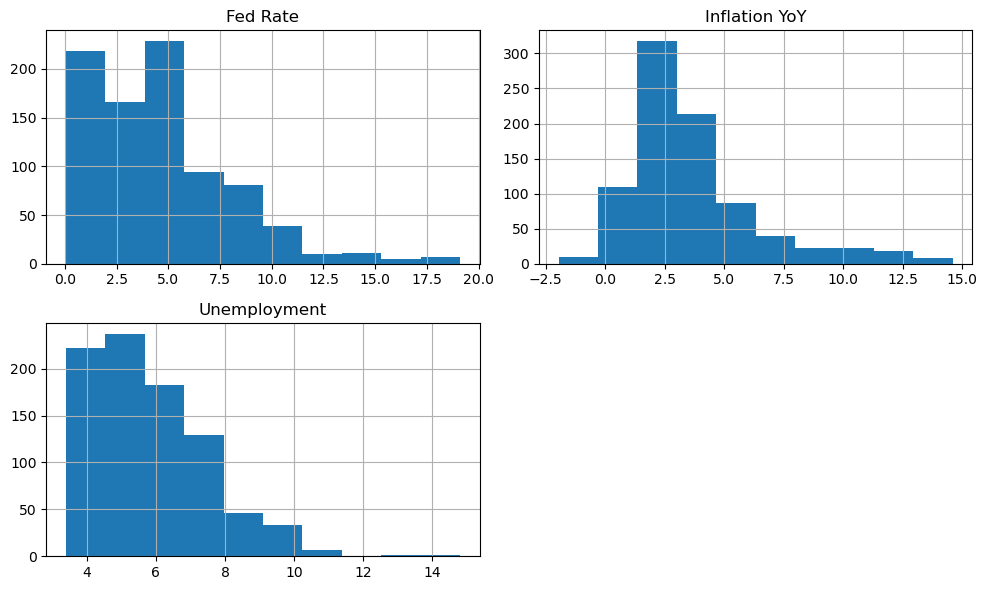

In [15]:
# Distribution Plots
df[["Fed Rate", "Inflation YoY", "Unemployment"]].hist(figsize=(10, 6))
plt.tight_layout()
plt.show()

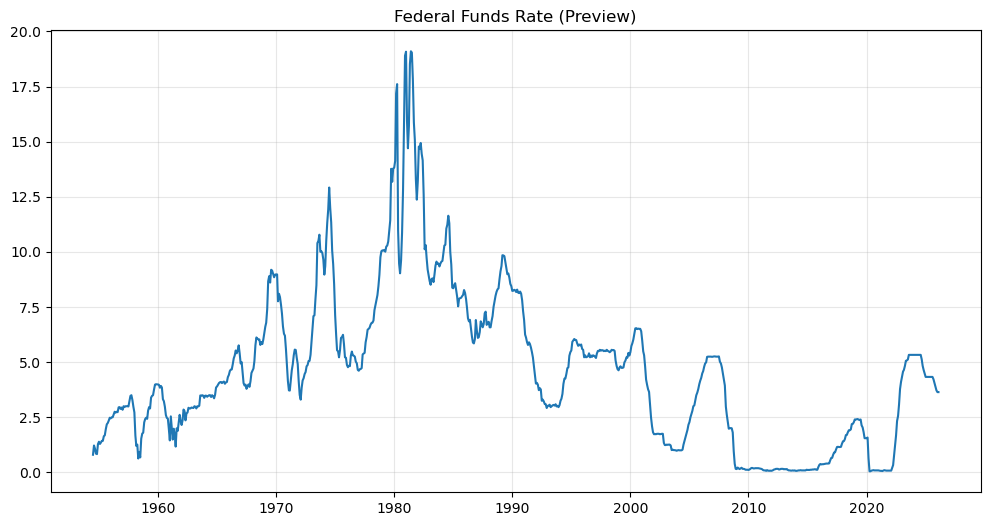

In [16]:
# Time Series Preview
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["Fed Rate"])
plt.title("Federal Funds Rate (Preview)")
plt.grid(alpha=0.3)
plt.show()

In [17]:
# Correlation Check
df[["Fed Rate", "Inflation YoY", "Unemployment"]].corr()

,Fed Rate,Inflation YoY,Unemployment
Fed Rate,1.000000,0.703877,0.064537
Inflation YoY,0.703877,1.000000,0.089357
Unemployment,0.064537,0.089357,1.000000


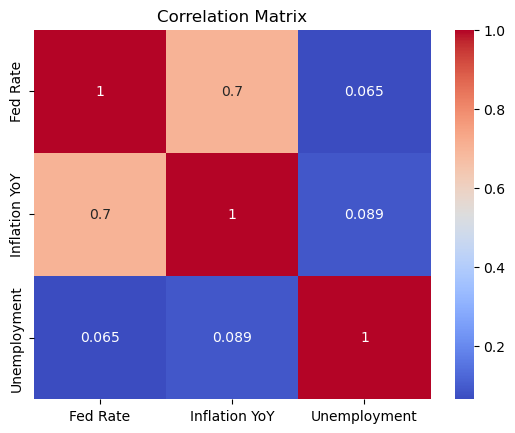

In [18]:
# Correlation Heatmap
import seaborn as sns

sns.heatmap(
    df[["Fed Rate", "Inflation YoY", "Unemployment"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix")
plt.show()

## 🔍 Initial Observations

- The Federal Funds Rate shows significant variation over time, reflecting changing monetary policy conditions.
- Inflation and unemployment exhibit different distributions and patterns, suggesting complex relationships.
- Correlation between variables exists but is not strong enough to imply simple linear relationships.
- Rolling averages help smooth volatility and will be useful in the main analysis notebook.

This exploratory analysis prepares the dataset for deeper interpretation and visualization in the next stage of the project.